# DROID-100 → S3 / OSS Lance → Doris

[简体中文](droid100_preview.html) | [English](droid100_preview.en.html) · [中文 Notebook](droid100_end_to_end.ipynb) | [English Notebook](droid100_end_to_end.en.ipynb)

## From a failed grasp to traceable training candidates

**A notebook you can run, explain, and export as a presentation page.** Each step has an input → processing → output diagram.

- Data: pinned `lerobot/droid_100`, 100 episodes and three cameras.
- Processing: SigLIP2 image embeddings, S3 / OSS Lance, and vector indexes.
- Analysis: Doris `vector_search()`, human review, failure distributions, and training candidates.

> Default **preview** mode explains the workflow offline with diagrams, source counts, and SQL. It does not download models, connect to S3 / OSS/Doris, or fabricate results.
> Configure your environment and switch to **live** to execute the actual workflow step by step. Your Doris build must support Lance Catalog and Vector Search.


In [1]:
from pathlib import Path
import os
import sys

# Locate the project before importing its shared modules.
PROJECT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                if (p / "pipeline/export_droid.py").is_file()), None)
if PROJECT is None:
    raise RuntimeError("Start Jupyter from the project root or notebooks directory")
sys.path.insert(0, str(PROJECT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / "work/notebook/matplotlib"))

import json
from getpass import getpass
from uuid import uuid4
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, SVG, Markdown, Code, Video
from dotenv import load_dotenv
from notebooks.demo_support import (
    run_export, connect_doris, run_sql, initialize_doris, load_annotations,
)
load_dotenv(PROJECT / ".env", override=False)

# Change MODE to live only when your S3 / OSS and Doris settings are ready.
MODE = "preview"
RUN_EXPORT = False
RUN_SETUP = False
IMPORT_LABELS = False
RESUME_EXPORT = False
DATASET_ROOT = os.getenv("NOTEBOOK_DATASET_ROOT", "oss://YOUR_BUCKET/robotics/droid100")
MAX_EPISODES = 100
FRAME_STRIDE = 15
DEVICE = "auto"
REFERENCE_SAMPLE = "0:observation.images.wrist_image_left:0"
RUN_ID = "nb_" + uuid4().hex[:12]
WORK = PROJECT / "work/notebook"
LABEL_DIR = WORK / "labels"
QUERY_DIR = WORK / "queries" / RUN_ID
LIVE = MODE == "live"
assert MODE in {"preview", "live"}
connection = None
counts = None
hits = pd.DataFrame()
coverage = distribution = reasons = training = pd.DataFrame()
print(f"Mode: {MODE} | run_id: {RUN_ID}")


Mode: preview | run_id: nb_65e4f1434b84


In [2]:
display(HTML("""
<style>
.jp-RenderedHTMLCommon h1 {color:#102a43;letter-spacing:-.03em}
.jp-RenderedHTMLCommon h2 {color:#176b87;margin-top:1.8em}
.jp-RenderedHTMLCommon table {font-size:14px}
.jp-OutputArea-output svg, .jp-OutputArea-output img {max-width:100%;height:auto}
.demo-note {padding:14px 18px;background:#eef6ff;border-left:4px solid #2563eb;border-radius:8px;color:#16324f}
</style>
"""))


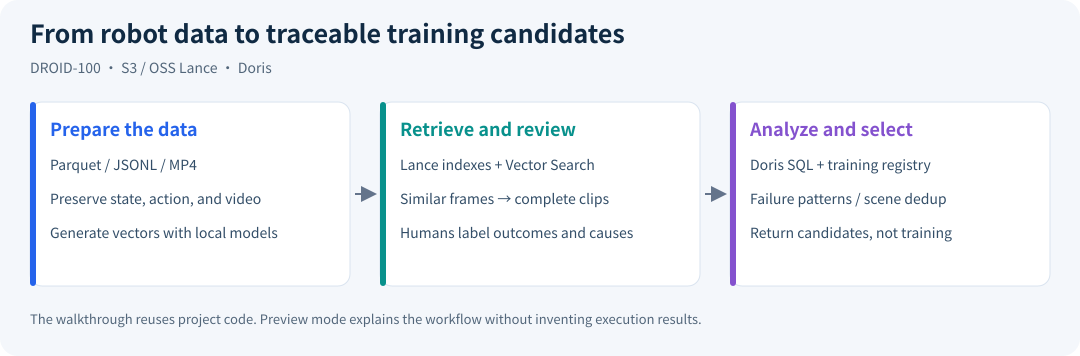

In [3]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/00_overview.svg")))


### Execution settings

Copy the root `.env.example` to `.env` and configure S3 / OSS and Doris. **Do not put credentials inside the notebook.**

| Setting | Meaning |
|---|---|
| `MODE="preview"` / `"live"` | Offline walkthrough / execution against your environment |
| `RUN_EXPORT=True` | Run the existing exporter: download, generate embeddings, write S3 / OSS, and build indexes |
| `RUN_SETUP=True` | Create the catalog and three analysis tables for the first time; otherwise keep False |
| `IMPORT_LABELS=True` | Import your two CSVs containing real review labels and training registry records |
| `RESUME_EXPORT=True` | Resume the same export configuration and preserve committed indexes |
| `FRAME_STRIDE=15` | Generate about one frame vector per second; set to 1 for every frame |
| `MAX_EPISODES=100` | Export all DROID-100 episodes; use a different prefix when trying only two |

The configuration cell generates a new `RUN_ID` each time. After human review, rerun only label import and later cells to keep the same run_id.
The Doris catalog warehouse must match DATASET_ROOT. The original first frame is only a connectivity example, not an asserted failure sample.


## 01 / What is the source data, and how is it imported?

Pinned v2.1 commit: `78f887947f976d85dd04594bcbd0b05c29893349`.
Each episode has synchronized state/action in Parquet, three camera views in MP4, and task/episode information in meta files.
The following counts describe the **source version**, not a completed export from this notebook.


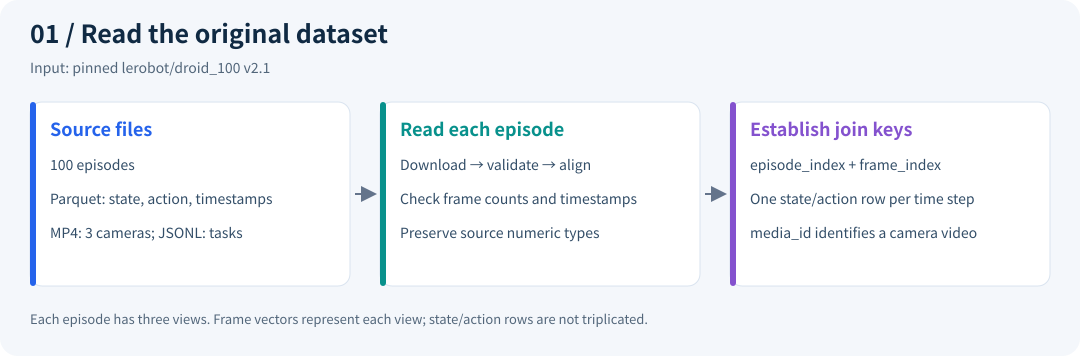

In [4]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/01_source.svg")))


In [5]:
source_scale = pd.DataFrame({
    "Source item": ["Episodes", "State/action steps", "Task entries", "MP4 videos",
                    "Frame vectors (stride=1)", "Frame vectors (stride=15)"],
    "Expected count": [100, 32212, 47, 300, 96636, 6591],
})
display(source_scale)


,Source item,Expected count
0,Episodes,100
1,State/action steps,32212
2,Task entries,47
3,MP4 videos,300
4,Frame vectors (stride=1),96636
5,Frame vectors (stride=15),6591


## 02 / How does video become a vector?

SigLIP2 generates a 768-dimensional vector for each sampled RGB image on your CPU/GPU. No online embedding API is required.
`state` and `action` preserve their original seven values without model processing. Original MP4 bytes are also preserved.
This version has no audio tracks, so an empty audio table is expected. Visual similarity alone does not establish action order or a failure cause.


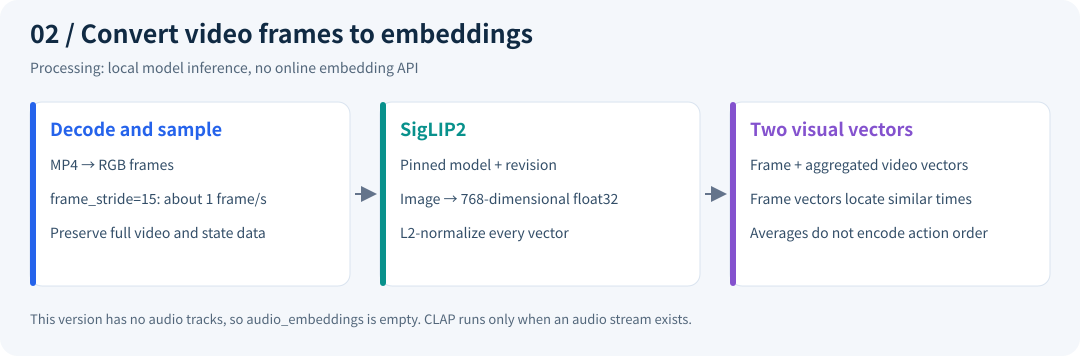

In [6]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/02_embedding.svg")))


## 03 / Write Lance, build indexes, and inspect the result

The following cell **calls the existing exporter once to perform steps 01–03**, including actual downloads, inference, writes, and indexing.
The notebook reuses the production pipeline. If a complete export already exists, keep `RUN_EXPORT=False` and inspect it directly.


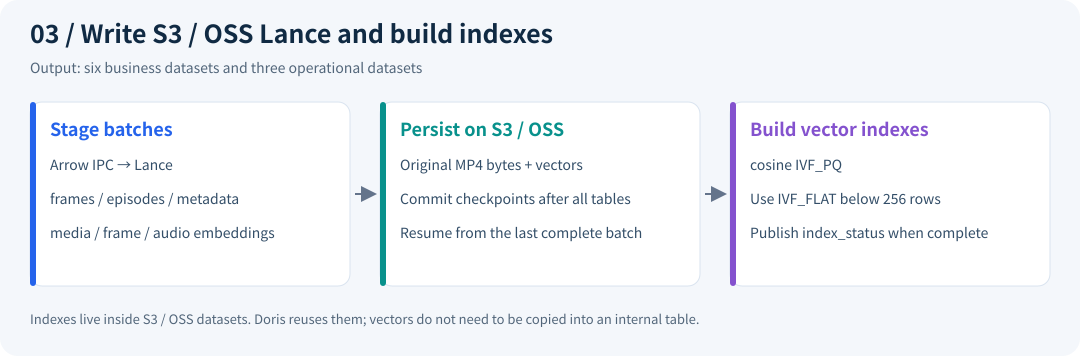

In [7]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/03_lance.svg")))


In [8]:
if LIVE:
    if "YOUR_BUCKET" in DATASET_ROOT or not DATASET_ROOT.startswith(("s3://", "oss://")):
        raise ValueError("Set DATASET_ROOT to your real S3 / OSS export prefix")
    WORK.mkdir(parents=True, exist_ok=True)
    if RUN_EXPORT:
        run_export(PROJECT, DATASET_ROOT, WORK / "export", MAX_EPISODES,
                   FRAME_STRIDE, DEVICE, RESUME_EXPORT)
    else:
        print("Reading an existing export; the export CLI was not run.")
else:
    print("Preview: download, inference, S3 / OSS writes and index construction were not executed.")


Preview: download, inference, S3 / OSS writes and index construction were not executed.


In [9]:
if LIVE:
    import lance
    from pipeline.export_droid import storage_options
    options = storage_options(DATASET_ROOT, None, None)
    def dataset(name):
        return lance.dataset(DATASET_ROOT.rstrip("/") + f"/{name}.lance", storage_options=options)
    checkpoint = dataset("export_checkpoints").to_table().to_pylist()
    ready = dataset("export_index_status").to_table().to_pylist()
    if not checkpoint[-1]["complete"] or not ready[0]["complete"]:
        raise RuntimeError("Data and indexes must both be complete")
    names = ["frames", "episodes", "media", "frame_embeddings", "audio_embeddings", "metadata"]
    counts = pd.DataFrame({"Dataset": names, "Actual rows": [dataset(n).count_rows() for n in names]})
    episode_ids = set(dataset("episodes").to_table(columns=["episode_index"])["episode_index"].to_pylist())
    source_manifest = dataset("export_manifest").to_table().to_pylist()[0]["config_json"]
    display(counts)
    display(pd.DataFrame([(f.name, str(f.type)) for f in dataset("frame_embeddings").schema],
                         columns=["Embedding field", "Arrow type"]))
    display(dataset("frames").head(5).to_pandas())
else:
    print("Preview: no exported dataset was read. Live mode shows actual counts and schema here.")


Preview: no exported dataset was read. Live mode shows actual counts and schema here.


## 04 / Connect Doris and verify the same Lance export

For initial setup, set `RUN_SETUP=True`. The helper builds and executes setup SQL from environment variables without printing credentials.
Keep it False for an existing catalog. If you use STS, configure a catalog supporting temporary credentials manually first.
Business data stays on S3 / OSS; Doris internal tables store retrieval hits, review labels, and the training registry.

For S3, set `AWS_REGION`, AWS credentials, and `NOTEBOOK_DATASET_ROOT=s3://YOUR_BUCKET/robotics/droid100` in `.env`. The URI selects the catalog template. Configure STS/IAM catalogs separately and keep `RUN_SETUP=False`. See the [S3 guide](../docs/STORAGE.md).


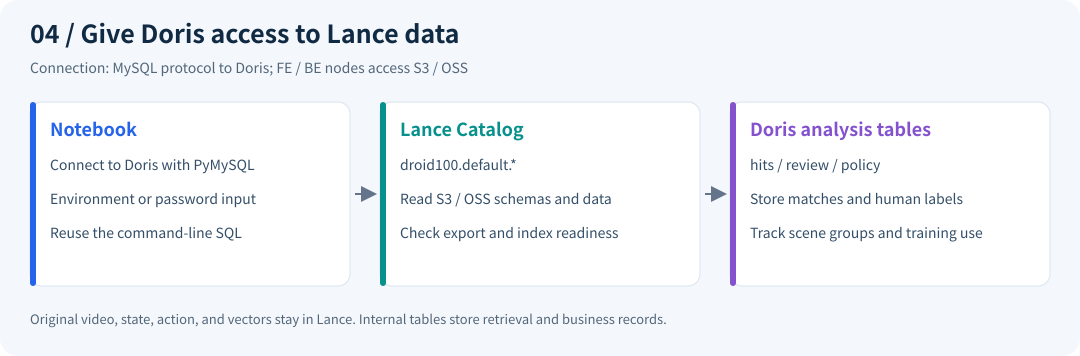

In [10]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/04_catalog.svg")))


In [11]:
if LIVE:
    password = os.environ.get("DORIS_PASSWORD")
    if password is None:
        password = getpass("Doris password: ")
    connection = connect_doris(password)
    del password
    if RUN_SETUP:
        setup_results = initialize_doris(connection, PROJECT, DATASET_ROOT)
        print("Initial catalog/table setup completed.")
    db_manifest = run_sql(connection,
        "SELECT config_json FROM droid100.`default`.export_manifest")[0]
    if len(db_manifest) != 1 or db_manifest.iloc[0]["config_json"] != source_manifest:
        raise RuntimeError("The Doris catalog does not match this export manifest")
    display(run_sql(connection, "SHOW INDEX FROM droid100.`default`.frame_embeddings")[0])
else:
    print("Preview: no database connection or DDL was executed.")


Preview: no database connection or DDL was executed.


## 05 / Vector Search: find scenes similar to the reference frame

Read the actual query vector from an exported sample-id and reuse the project's SQL templates. Camera/model filters apply before retrieval.
Retrieve up to 2,000 frames, then deduplicate by episode and keep up to 50. Both successes and failures remain eligible for comparison.
The template is shown below; live mode inserts a real 768-dimensional vector and executes it.

For a newly captured incident image, use `python -m doris.prepare_query --image ...` to generate a vector with the same model. See [the Doris guide](../doris/README.md).


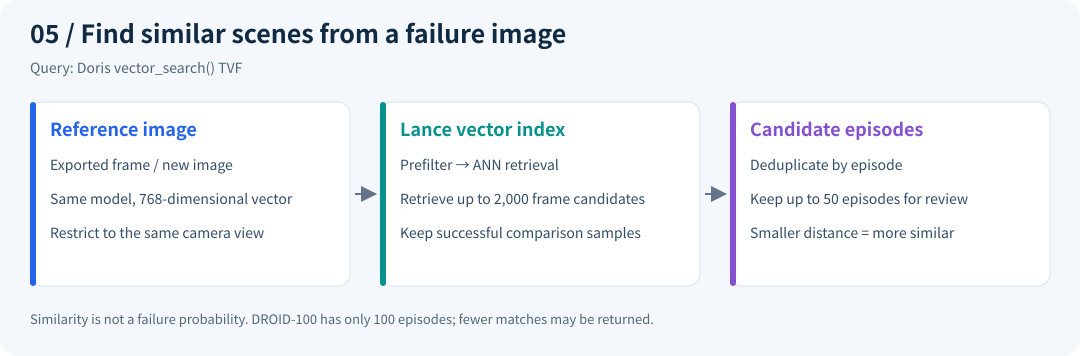

In [12]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/05_search.svg")))


In [13]:
display(Code((PROJECT / "doris/sql/02_vector_search.sql").read_text(), language="sql"))


-- Render this template with python -m doris.prepare_query.
-- Vector Search runs in Lance and reuses the cosine index built by the pipeline.
-- Use a new run ID for each query; this INSERT does not delete stale run results.
-- Prefilter before candidate generation; do not prefilter to failure-only rows.
-- Retrieve up to 2000 frames, then deduplicate to at most 50 other episodes.
-- Increase top_k if nearby frames consume too much of the candidate budget.
-- nprobes/refine_factor are example query parameters, not universal optima.
-- 1 - _distance is a display similarity only because metric is cosine.
INSERT INTO internal.droid100_analysis.grasp_hits
SELECT * FROM (
    WITH candidates AS (
        SELECT episode_index, sample_id, media_id, frame_index,
               `timestamp` AS timestamp_s, _distance
        FROM vector_search(
            "table" = "droid100.default.frame_embeddings",
            "column" = "embedding",
            "query_vector" = "{{QUERY_VECTOR_JSON}}",
            "top_k" = "2000",
            "metric" = "cosine",
            "nprobes" = "20",
            "refine_factor" = "10",
            "filter" = "camera = '{{CAMERA}}' AND model = 'google/siglip2-base-patch16-224' AND model_revision = '75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2' AND episode_index >= 0 AND episode_index < 100 AND episode_index != {{REFERENCE_EPISODE}}",
            "use_index" = "true"
        )
    ), ranked AS (
        SELECT *, ROW_NUMBER() OVER (
            PARTITION BY episode_index ORDER BY _distance ASC, frame_index
        ) AS rn
        FROM candidates
    )
    SELECT '{{RUN_ID}}', episode_index, sample_id, media_id,
           frame_index, timestamp_s, 1 - _distance AS similarity
    FROM ranked WHERE rn = 1
    ORDER BY _distance ASC, episode_index LIMIT 50
) candidate_rows;

SHOW INDEX FROM droid100.`default`.frame_embeddings;

In [14]:
if LIVE:
    from doris.prepare_query import read_reference, render
    reference = read_reference(DATASET_ROOT, REFERENCE_SAMPLE, options)
    render(reference, QUERY_DIR, RUN_ID)
    run_sql(connection, (QUERY_DIR / "02_vector_search.sql").read_text())
    with connection.cursor() as cursor:
        cursor.execute("SELECT * FROM internal.droid100_analysis.grasp_hits "
                       "WHERE run_id=%s ORDER BY similarity DESC", (RUN_ID,))
        hits = pd.DataFrame(cursor.fetchall(), columns=[c[0] for c in cursor.description])
    display(hits)
    if not hits.empty:
        fig, ax = plt.subplots(figsize=(10, 3))
        hits.head(15).plot.bar(x="episode_index", y="similarity", ax=ax, color="#2563eb", legend=False)
        ax.set(title="Retrieved episodes: visual similarity", xlabel="Episode", ylabel="Cosine similarity")
        plt.tight_layout()
        plt.show()
else:
    print("Preview: no nearest-neighbor results are fabricated.")


Preview: no nearest-neighbor results are fabricated.


## 06 / Play video, inspect actions, and import review labels

Use the candidate's `media_id` to find its video and `(episode_index, frame_index)` to find state/action.
Start with the surrounding window, then review a complete grasp attempt and record its outcome, cause, quality, and time bounds.
Do not automatically treat `next.reward` or `next.done` as a grasp outcome.


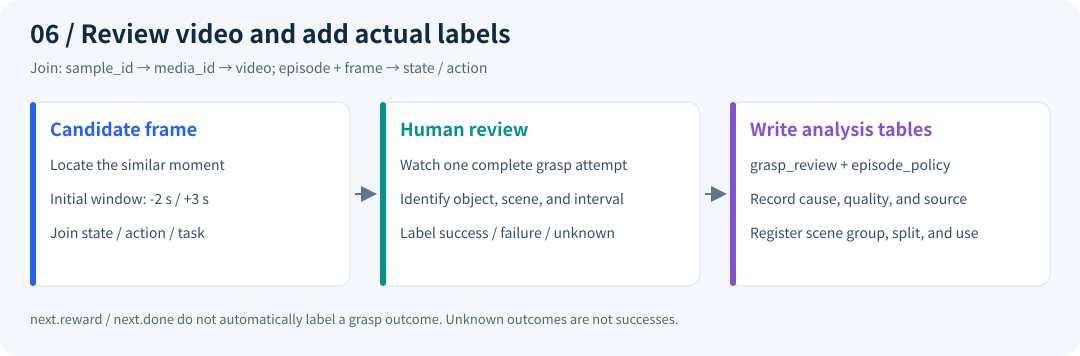

In [15]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/06_review.svg")))


In [16]:
if LIVE:
    review_results = run_sql(connection, (QUERY_DIR / "03_review_clips.sql").read_text())
    display(review_results[0])
    display(review_results[1].head(30))
    if not hits.empty:
        import av
        from pipeline.export_media import extract
        # Change this row number to inspect a different retrieved episode.
        selected = hits.iloc[0]
        media_id = str(selected["media_id"])
        video_path = WORK / "media" / (media_id.replace(":", "_") + ".mp4")
        if not video_path.exists():
            extract(DATASET_ROOT, media_id, video_path, options)
        # Decode a still even when the browser cannot play the source AV1 codec.
        with av.open(str(video_path)) as container:
            for number, frame in enumerate(container.decode(video=0)):
                if number == int(selected["frame_index"]):
                    display(frame.to_image())
                    break
        display(Video(filename=str(video_path), embed=True, width=640))
        print(f"Media: {media_id}; inspect the complete attempt before assigning labels.")
else:
    print("Preview: video and action rows appear after a real search.")


Preview: video and action rows appear after a real search.


### Supply two sets of real business records

Fill `work/notebook/labels/grasp_review.csv` and `episode_policy.csv`; the next cell copies empty templates on its first run.
The review's run_id, sample_id, and episode_index must match the current search. Outcome is success, failure, or unknown.
episode_policy must cover **every exported episode**, including validation/test data. See [field rules](../doris/README.md).
Without labels, retrieval can still be demonstrated, but no valid failure rate can be calculated.

After labeling, set only `IMPORT_LABELS` to True and continue from this cell. Do not rerun the configuration cell that generates a new RUN_ID.
You can run `IMPORT_LABELS = True` in a new cell to preserve the current search.


In [17]:
if LIVE:
    import shutil
    LABEL_DIR.mkdir(parents=True, exist_ok=True)
    for name in ("grasp_review.csv", "episode_policy.csv"):
        target = LABEL_DIR / name
        if not target.exists():
            shutil.copyfile(PROJECT / "doris/templates" / name, target)
    print(f"Current review run: {RUN_ID}")
    if IMPORT_LABELS:
        imported = load_annotations(connection, PROJECT, LABEL_DIR / "grasp_review.csv",
                                    LABEL_DIR / "episode_policy.csv", RUN_ID, hits, episode_ids)
        display(pd.DataFrame(imported.items(), columns=["Table", "Imported rows"]))
    else:
        print("Label import skipped. Fill the CSVs, set IMPORT_LABELS=True, and rerun this cell.")
else:
    print("Preview: label templates remain empty; no outcomes are invented.")


Preview: label templates remain empty; no outcomes are invented.


## 07 / Where do failures concentrate?

First display review coverage, then failure rates by object/scene, followed by failure stage/reason distributions.
The denominator includes only reviewed, usable, task-matched attempts with known outcomes.
These results describe the retrieved cohort, not the robot's deployment-wide failure rate.


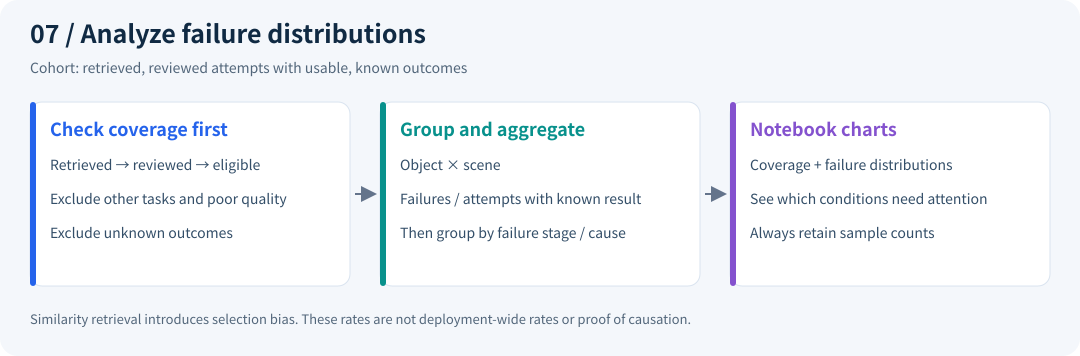

In [18]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/07_analysis.svg")))


In [19]:
if LIVE:
    coverage, distribution, reasons = run_sql(connection, (QUERY_DIR / "04_failure_distribution.sql").read_text())
    display(coverage)
    display(distribution)
    display(reasons)
    if distribution.empty:
        print("No eligible known outcomes. Review clips and import labels before interpreting failure rates.")
    else:
        view = distribution.copy()
        for field in ("failure_pct", "reviewed_known_clips", "failed_clips"):
            view[field] = pd.to_numeric(view[field], errors="raise")
        view["Group"] = view["object_type"].fillna("unknown") + " / " + view["scene_type"].fillna("unknown")
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        view.plot.barh(x="Group", y="failure_pct", ax=axes[0], color="#d97706", legend=False)
        axes[0].set(title="Failure rate within reviewed cohort", xlabel="Failure (%)", ylabel="Object / scene", xlim=(0, 100))
        view.plot.barh(x="Group", y=["reviewed_known_clips", "failed_clips"], ax=axes[1], color=["#08918c", "#d97706"])
        axes[1].set(title="Always inspect the denominator", xlabel="Reviewed attempts", ylabel="")
        plt.tight_layout()
        plt.show()
else:
    print("Preview: failure charts require real review labels; no percentages are synthesized.")


Preview: failure charts require real review labels; no percentages are synthesized.


## 08 / Select candidates for additional training

Exclude unknown training membership, already trained data, poor-quality clips, invalid time intervals, non-training splits, and scene groups spanning splits.
Deduplicate by scene group within each object/scene/training-use bucket and retain at most 20 clips per bucket.
Success clips are behavior-cloning positives; failures are diagnosis or critic candidates, not automatically correct action targets.


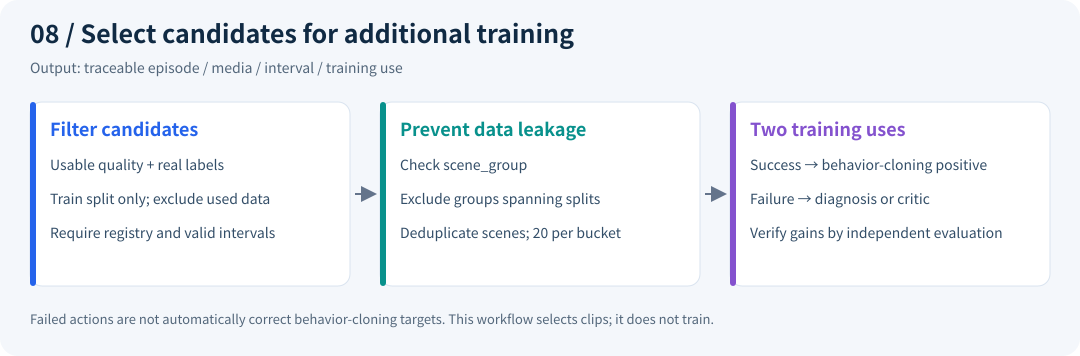

In [20]:
display(SVG(filename=str(PROJECT / "notebooks/assets/en/08_training.svg")))


In [21]:
if LIVE:
    mixed_groups, training = run_sql(connection, (QUERY_DIR / "05_select_training_samples.sql").read_text())
    display(mixed_groups)
    display(training)
    if not mixed_groups.empty:
        print("Mixed-split groups were excluded. Correct the group registry before training.")
    if training.empty:
        print("No eligible candidates. Inspect review coverage and the complete episode policy.")
    else:
        target = QUERY_DIR / "training_candidates.csv"
        training.to_csv(target, index=False)
        print(f"Saved {len(training)} training candidates to {target}")
    report_dir = QUERY_DIR / "report"
    report_dir.mkdir(parents=True, exist_ok=True)
    for name, table in {"hits": hits, "coverage": coverage, "failure_distribution": distribution,
                        "failure_reasons": reasons, "training_candidates": training}.items():
        table.to_csv(report_dir / f"{name}.csv", index=False)
else:
    print("Preview: this section defines selection rules; it does not claim training results.")


Preview: this section defines selection rules; it does not claim training results.


## Use the notebook as a presentation page

**Live presentation:** run in JupyterLab and collapse code to show diagrams, video, tables, and charts.

**Share a static page:** save the executed notebook, then export from the project root:

```bash
jupyter nbconvert notebooks/droid100_end_to_end.en.ipynb \
  --to html --no-input --embed-images --output-dir work/presentation
```

The HTML opens in a browser without Python. Saved charts and embedded video remain visible, but HTML does not rerun Python or SQL.
If live outputs were not executed and saved, the page will not contain real analysis results. Review videos, business data, and error outputs before sharing.
Hiding inputs does not remove sensitive material from outputs.

The included `droid100_preview.en.html` is an **executed preview-mode walkthrough**, not an S3 / OSS/Doris execution report.
To refresh both language pages with working relative language links, save both notebooks and run `python -m notebooks.export_presentations`.
Keep the two generated HTML files together when sharing. This helper exports saved outputs without executing cells.

References: [nbconvert HTML export](https://nbconvert.readthedocs.io/en/latest/usage.html)
· [Doris Lance Catalog / Vector Search](https://doris.apache.org/docs/4.x/lakehouse/catalogs/lance-catalog/)


In [22]:
if connection is not None:
    connection.close()
    connection = None
print("Session finished. Reconnect at step 04 before running more database queries.")


Session finished. Reconnect at step 04 before running more database queries.
